# Hierarchical Clustering Notebook

#### Importing needed packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### Reading the cleaned dataset

In [2]:
import sys
sys.path.append('..')
from src.data import load_data

df = load_data('../data/cleaned_log_data.csv')
df.head()

,Unnamed: 0,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0,2,3,9.446992,9.175438,8.930891,5.370638,7.891705,7.199678
1,1,2,3,8.861917,9.191259,9.166284,7.474772,8.099858,7.482682
2,2,2,3,8.756840,9.083529,8.947026,7.785721,8.165364,8.967632
3,3,1,3,9.492960,7.087574,8.348064,8.764834,6.230481,7.489412
4,4,2,3,10.026413,8.596189,8.881697,8.272826,7.483244,8.553718


In [3]:
df.shape

(395, 9)

In [4]:
features = ['Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen']

X_data = np.asanyarray(df[features])
X_data

array([[ 9.44699227,  9.17543832,  8.93089098,  5.37063803,  7.89170466,
         7.19967835],
       [ 8.861917  ,  9.19125948,  9.16628399,  7.47477218,  8.09985791,
         7.48268183],
       [ 8.75683981,  9.08352921,  8.94702566,  7.7857209 ,  8.16536363,
         8.96763167],
       ...,
       [10.57717155,  7.26682735,  6.63987583,  8.41427414,  4.54329478,
         7.7608932 ],
       [ 9.58410839,  9.64788537, 10.3170531 ,  6.08221891,  9.60521628,
         7.53262362],
       [ 9.23902501,  7.59186171,  7.71110125,  6.94601399,  5.12989871,
         7.66199756]], shape=(395, 6))

#### Visualizing the scaled data distribution

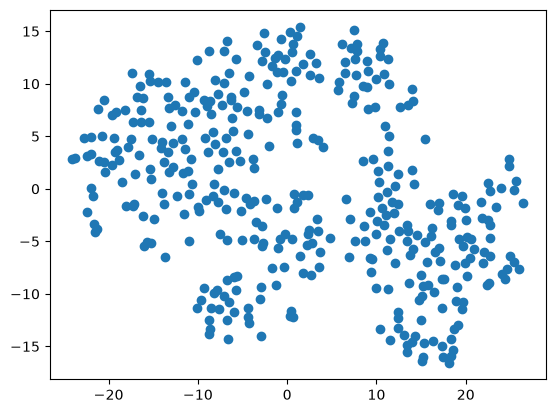

In [5]:
from src.clustering import tsne_model
from sklearn.preprocessing import StandardScaler
X_s = StandardScaler().fit_transform(X_data)
model = tsne_model(X_s)
plt.scatter(model[:,0] , model[:,1])

#### Model training

In [6]:
from src.clustering import Hierarchical_cluster_scp
from scipy.cluster.hierarchy import dendrogram

model = Hierarchical_cluster_scp(X_data, 'complete')

K : 2 , silhouette Score : 0.2511596339684152
                	calinski harabasz score : 154.48620734648904
                	davies bouldin score : 1.48685340307711


K : 3 , silhouette Score : 0.19549248476994263
                	calinski harabasz score : 110.85704170206552
                	davies bouldin score : 1.5077874321803468


K : 4 , silhouette Score : 0.15490850977796528
                	calinski harabasz score : 86.01450324214817
                	davies bouldin score : 1.5942572753658801


K : 5 , silhouette Score : 0.10673624367333553
                	calinski harabasz score : 72.06501600478794
                	davies bouldin score : 2.060188056288178


K : 6 , silhouette Score : 0.08980372837962751
                	calinski harabasz score : 63.43636509864069
                	davies bouldin score : 1.7373780036473974


K : 7 , silhouette Score : 0.10050422292551223
                	calinski harabasz score : 64.88733994107983
                	davies bouldin score : 1.6731290

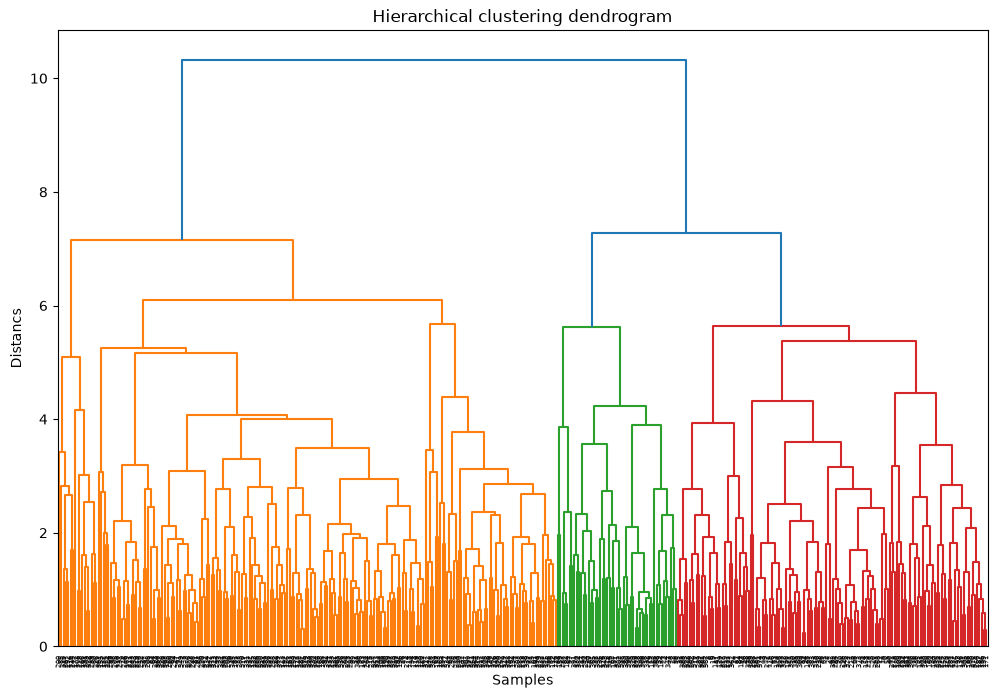

In [7]:
plt.figure(figsize=(12, 8))
dendrogram(model)

plt.xlabel('Samples')
plt.ylabel('Distancs')
plt.title('Hierarchical clustering dendrogram')
plt.show()

#### Selecting a distance of dendrogram for clustering
##### According to results of scores and dendrogram, k = 2 is main dividsion and k = 3 is more precisely division.

In [8]:
from scipy.cluster.hierarchy import fcluster

In [9]:
labels_2 = fcluster(model, 2, criterion= 'distance')
labels_3 = fcluster(model, 3, criterion= 'distance')

cluster_size_2 = np.bincount(labels_2)
cluster_size_3 = np.bincount(labels_3)

print(cluster_size_2)
print(cluster_size_3)

[ 0  3  2  1  1  2  4  3  1  3  1  1  5  9  2  5  1 15  1  3  2  5  3  5
  3  8  7  1  2  6  6  8 15 12 10  3  2  1  2  1  3  2  2 11  2  7 13  7
  2  3  2  3  3  5  3  2  5  3 10  6  3  1  5  5  9  5  2  5  2 13  7 10
  3  5 15  4  3  5  6  5  1  5  6  4  7]
[ 0  6  1  2  7  1  4  1 14  8 16  5 13 19 14 45  3  2  1  3  5  2 40  2
  5 11 10 13 10 19 12  2 30  3 24  3  5 12 22]


##### k = 2 is the more balanced division

#### Visualizing the clustering result

Text(0.5, 1.0, 'Hierarchical Clustering')

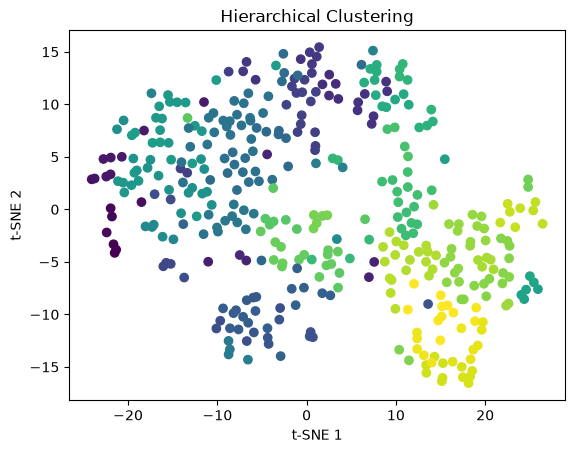

In [10]:
X_scaled = StandardScaler().fit_transform(X_data)

tsne_vis = tsne_model(X_scaled)

plt.scatter(tsne_vis[: , 0], tsne_vis[: , 1] , c = labels_2)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('Hierarchical Clustering')

#### Clustering Interpratation

In [13]:
df_exp = df.copy()
df_exp['labels'] = labels_2

In [14]:
cluster_profile = (df_exp.groupby('labels')[features].agg(['mean', 'median']))
cluster_profile

Fresh                Milk             Grocery               Frozen  \
            mean    median      mean    median      mean     median      mean   
labels                                                                          
1       6.269001  6.297109  6.863909  6.802395  7.461387   7.417580  6.110213   
2       7.087103  7.087103  6.882366  6.882366  5.582109   5.582109  6.304870   
3       6.001415  6.001415  5.541264  5.541264  6.415097   6.415097  6.652863   
4       7.533694  7.533694  6.359574  6.359574  6.350886   6.350886  6.857514   
5       9.462936  9.462936  5.578796  5.578796  5.849868   5.849868  7.618028   
...          ...       ...       ...       ...       ...        ...       ...   
80      7.089243  7.089243  7.864420  7.864420  9.028339   9.028339  5.998937   
81      6.705570  6.823286  9.330306  9.214830  9.899457  10.007082  7.233151   
82      7.530652  7.447844  9.050330  9.015738  9.506692   9.463629  5.612468   
83      7.600576  7.601658  8.858721  8.971768  9.533551   9.555052  6.989846   
84      8.135116  7.967973  8.693518  8.787526  9.185529   9.206935  6.645081   

                 Detergents_Paper           Delicassen            
          median             mean    median       mean    median  
labels                                                            
1       6.028279         4.890940  4.510860   5.699459  5.560682  
2       6.304870         4.418695  4.418695   5.839982  5.839982  
3       6.652863         4.007333  4.007333   4.158883  4.158883  
4       6.857514         8.468633  8.468633   5.318120  5.318120  
5       7.618028         3.532380  3.532380   6.625167  6.625167  
...          ...              ...       ...        ...       ...  
80      5.998937         8.254269  8.254269   5.717028  5.717028  
81      7.290293         9.019527  9.134107   7.147147  6.693324  
82      5.537861         8.776755  8.819171   7.812605  7.803543  
83      6.970796         8.608678  8.609937   7.662486  7.677169  
84      6.836259         8.422482  8.369853   6.962023  6.969791  

[84 rows x 12 columns]

#### Cluster profile with Z-Score, it shows the different between cluster mean and overal mean for any features

In [15]:
df_Z = pd.DataFrame(index=sorted(df_exp['labels'].unique()))

for feature in features:
    cluster_mean = df_exp.groupby('labels')[feature].mean()
    overall_mean = df_exp[feature].mean()
    overall_std = df_exp[feature].std()
    
    df_Z[feature] = (cluster_mean - overall_mean) / overall_std

df_Z

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
1,-2.379685,-1.255747,-0.941145,-1.174282,-1.181930,-1.112350
2,-1.647950,-1.237269,-2.801188,-1.000903,-1.476398,-0.971698
3,-2.619021,-2.579838,-1.976726,-0.690950,-1.732902,-2.654350
4,-1.248507,-1.760633,-2.040280,-0.508670,1.048939,-1.494042
5,0.477063,-2.542264,-2.536169,0.168710,-2.029059,-0.185787
...,...,...,...,...,...,...
80,-1.646036,-0.254142,0.609769,-1.273394,0.915272,-1.094766
81,-1.989204,1.213347,1.471971,-0.174095,1.392449,0.336676
82,-1.251228,0.933065,1.083226,-1.617617,1.241068,1.002749
83,-1.188686,0.741246,1.109810,-0.390804,1.136264,0.852491


## Conclusion

After evaluating Hiearchical with different distance of dendrogram, the best result was obtained with **K = 2**, achieving a **Silhouette Score of 0.2511**.

This score indicates a relatively weak separation between the clusters. Therefore, while Hierarchical was able to identify some structure in the dataset, the resulting clusters are not strongly separated.

It can shows that the data has no hierarchical structure and this algorithm, is not suitable for this data.

The comparison between Hierarchical algorithm and clustering suggests that the dataset is better represented by relatively flat partitions rather than a hierarchical cluster structure.